# L1-регуляризатор. Отличия между L1- и L2-регуляризаторами

## Задача 1:
Дана следующая обучающая выборка для задачи бинарной классификации:
```python
data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]
```               

Вам необходимо продолжить программу для вычисления вектора параметров:

$w=[w0,w1,w2,w3,w4]^T$

которым описывается разделяющая гиперплоскость в соответствии с выражением:

$w1⋅x1+w2⋅x2+w3⋅x3+w4⋅x4+w0=0$

Вектор параметров ww следует искать с помощью алгоритма стохастического градиентного спуска (SGD) с L1-регуляризатором:

$wn=w_{n−1}−η⋅(\frac{∂Qk(w)}{∂w}+λ⋅sign(\tilde w))$

где $\tilde w=[0,w1,⋯ ,w4]^T$ - вектор с исключенным первым параметром w0​; k - случайно выбранный образ из обучающей выборки; Qk(w) - усеченный эмпирический риск:

$Qk(w)=\frac{1}{K}\sum_{i=k}^{k+K−1}L_i(w)$

То есть, псевдоградиент вычисляется не по одному образу k, а по образам в диапазоне [k; k+K) (всего K образов).

В качестве функции потерь следует выбрать логарифмическую функцию:

$L_i(w)=log_2(1+e^{−M_i})=log_2(1+e^{−w^T⋅x_i⋅y_i})$

Ее производная по вектору параметров w, равна:

$\frac{∂Li(w)}{∂w}=−\frac{{e^−w^T⋅x_i⋅y_i}⋅x_i^T⋅y_i}{(1+e^{−w^T⋅x_i⋅y_i})⋅ln(2)}$

Продолжите программу, в которой сформирована обучающая выборка, заданы функции потерь и ее производной, а также начальные значения и параметры для алгоритма SGD:
```python
import numpy as np

# логарифмическая функция потерь
def loss(w, x, y):
    M = np.dot(w, x) * y
    return np.log2(1 + np.exp(-M))

# производная логарифмической функции потерь по вектору w
def df(w, x, y):
    M = np.dot(w, x) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))

data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1], 0.8*x[0], (x[0]+x[1])/2] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = np.zeros(len(x_train[0]))  # начальные нулевые весовые коэффициенты
nt = np.array([0.5] + [0.01] * (len(w) - 1))  # шаг обучения для каждого параметра w0, w1, w2, ...
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)
lm_l1 = 0.05 # параметр лямбда для L1-регуляризатора

Qe = # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел
```
На каждой итерации алгоритма SGD с L1-регуляризатором необходимо выбирать начальное значение k командой:
```python
k = np.random.randint(0, n_train-batch_size-1) # n_train - размер выборки (массива x_train)
```
и из массива x_train выбирать векторы признаков {xi} для вычисления псевдоградиента по образам от k до k + batch_size (команда range(k, k+batch_size)).

Также на каждой итерации нужно пересчитывать значение Qe экспоненциального скользящего среднего по формуле:

$Qe=λ⋅Qk(w)+(1−λ)⋅Qe$

Вычисленные параметры вектора w следует сохранить в виде списка или кортежа с именем w. Также нужно вычислить итоговое значение среднего эмпирического риска для обученной модели по формуле:

$Q(a,X)=\frac{1}{n}⋅\sum_{i=1}^{n}[M_i<0]$

Вычисленное значение Q(a,X) сохраните в переменной Q, а последнее значение Qe - в переменной Qe.

Домашнее задание: проанализируйте полученные коэффициенты ww, посмотрите как они изменятся, если применить L2-регуляризатор.

w = [-3.67012934  0.12260854  0.66859677  0.05038683  0.39510265]
Q = 0.09
Qe = 0.7925973483927081


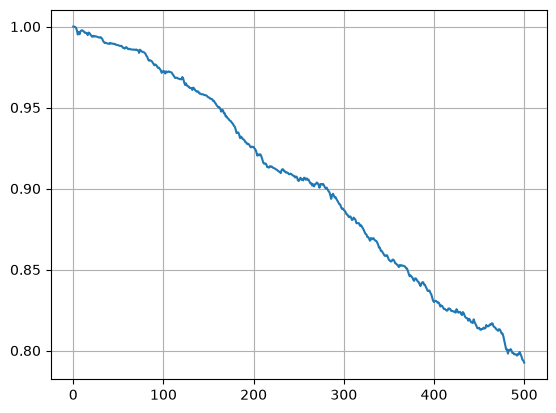

In [15]:
import numpy as np
import matplotlib.pyplot as plt


# логарифмическая функция потерь
def loss(w, x, y):
    M = np.dot(w, x) * y
    return np.log2(1 + np.exp(-M))


# производная логарифмической функции потерь по вектору w
def df(w, x, y):
    M = np.dot(w, x) * y
    return -(np.exp(-M) * x.T * y) / ((1 + np.exp(-M)) * np.log(2))


data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

x_train = np.array([[1, x[0], x[1], 0.8*x[0], (x[0]+x[1])/2] for x in data_x])
y_train = np.array(data_y)

n_train = len(x_train)  # размер обучающей выборки
w = np.zeros(len(x_train[0]))  # начальные нулевые весовые коэффициенты
nt = np.array([0.5] + [0.01] * (len(w) - 1))  # шаг обучения для каждого параметра w0, w1, w2, ...
lm = 0.01  # значение параметра лямбда для вычисления скользящего экспоненциального среднего
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)
lm_l1 = 0.05 # параметр лямбда для L1-регуляризатора

Qe = np.mean([loss(w, x, y) for x, y in zip(x_train, y_train)]) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

Q_plot = [Qe]

# здесь продолжайте программу
for i in range(N):
    k = np.random.randint(0, n_train - batch_size - 1)
    
    grad = np.zeros(len(w))
    loss_sum = 0.0
    for j in range(k, k + batch_size):
        x = x_train[j]
        y = y_train[j]
        grad += df(w, x, y)
        loss_sum += loss(w, x, y)
    
    grad = grad / batch_size
    Qk = loss_sum / batch_size
    
    # добавляем L1-регуляризатор (без w0)
    w_tilde = np.copy(w)
    w_tilde[0] = 0
    grad += lm_l1 * np.sign(w_tilde)
    
    w = w - nt * grad
    Qe = lm * Qk + (1 - lm) * Qe

    Q_plot.append(Qe)

M = np.dot(x_train, w) * y_train
Q = np.mean(M < 0)

print(f"w = {w}")
print(f"Q = {Q}")
print(f"Qe = {Qe}")

#  Построение графика 
plt.plot(Q_plot)
plt.grid()
plt.show()

## Задача 2:
Дана функция:

$f(x)=−0.5⋅x^2+0.1⋅x^3+cos(3x)+7$

Необходимо выполнить ее аппроксимацию (восстановление) на интервале [-4, 6] моделью вида:

$a(x)=w0+\sum_{i=1}^{N−1}w_i⋅x_i$

при N=5.

Вектор параметров $w=[w_0,w_1,⋯ ,w_{N−1}]^T$ следует искать с помощью алгоритма стохастического градиентного спуска (SGD) с L1-регуляризатором:

$wn=w_{n−1}−η⋅(\frac{∂Qk(w)}{∂w}+λ⋅sign(\tilde w))$

где $\tilde w=[0,w1,⋯ ,wN−1]^T$ - вектор с исключенным первым параметром w0​; k - случайно выбранный образ из обучающей выборки; Qk(w) - усеченный эмпирический риск:

$Qk(w)=\frac{1}{K}\sum_{i=k}^{k+K−1}(a(x_i,w)−y_i)^2=\frac{1}{K}\sum_{i=k}^{k+K−1}(w^T⋅x_i−y_i)^2$

где $x_i=[1,x,x^2,⋯ ,x^{N−1}]^T$ - вектор признаков i-го образа; yi​ - значение функции f(x) в i-й точке.

Производная усеченного показателя качества может быть записана в следующем векторно-матричном виде:

$\frac{∂Qk(w)}{∂w}=\frac{2}{K}\sum_{i=k}^{k+K−1}(w^T⋅x_i−y_i)⋅x_i^T$

То есть, псевдоградиент вычисляется не по одному образу k, а по образам в диапазоне [k; k+K) (всего K образов).

Продолжите программу, в которой объявлена функция f(x) с именем func, заданы значения функции по оси абсцисс и ординат, а также начальные значения и параметры для алгоритма SGD с L1-регуляризатором:
```python
import numpy as np

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return -0.5 * x ** 2 + 0.1 * x ** 3 + np.cos(3 * x) + 7

# модель
def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv

# функция потерь
def loss(w, x, y):
    return (model(w, x) - y) ** 2

# производная функции потерь
def dL(w, x, y):
    xv = np.array([x ** n for n in range(len(w))])
    return 2 * (model(w, x) - y) * xv

coord_x = np.arange(-4.0, 6.0, 0.1)
coord_y = func(coord_x)

N = 5 # сложность модели (полином степени N-1)
lm_l1 = 2.0 # коэффициент лямбда для L1-регуляризатора
sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002]) # шаг обучения для каждого параметра w0, w1, w2, w3, w4
w = np.zeros(N) # начальные нулевые значения параметров модели
n_iter = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)

Qe = # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел
```
На каждой итерации алгоритма SGD с L1-регуляризатором необходимо выбирать начальное значение k командой:
```python
k = np.random.randint(0, sz-batch_size-1) # sz - размер выборки (массива coord_x)
```
и из массива coord_x формировать векторы признаков:

$x_i=[1,x,x^2,⋯ ,x^{N−1}]^T$

для вычисления псевдоградиента Qk по образам от k до k + batch_size (команда range(k, k+batch_size))

Также на каждой итерации нужно пересчитывать значение Qe экспоненциального скользящего среднего по формуле:

$Qe=λ⋅Qk(w)+(1−λ)⋅Qe$

Вычисленные параметры вектора ww следует сохранить в виде списка или кортежа с именем w. Также нужно вычислить итоговое значение среднего эмпирического риска для обученной модели по формуле:

$Q(a,X)=\frac{1}{n}⋅\sum_{i=1}^{n}(a(x_i)−f(x_i))^2$

Вычисленное значение Q(a,X) сохраните в переменной Q, а последнее значение Qe - в переменной Qe.

Домашнее задание: оцените качество восстановления функции f(x) без регуляризаторов и с L2-регуляризатором.

In [20]:
import numpy as np

# исходная функция, которую нужно аппроксимировать моделью a(x)
def func(x):
    return -0.5 * x ** 2 + 0.1 * x ** 3 + np.cos(3 * x) + 7


# модель
def model(w, x):
    xv = np.array([x ** n for n in range(len(w))])
    return w.T @ xv


# функция потерь
def loss(w, x, y):
    return (model(w, x) - y) ** 2


# производная функции потерь
def dL(w, x, y):
    xv = np.array([x ** n for n in range(len(w))])
    return 2 * (model(w, x) - y) * xv


coord_x = np.arange(-4.0, 6.0, 0.1)
coord_y = func(coord_x)

N = 5 # сложность модели (полином степени N-1)
lm_l1 = 2.0 # коэффициент лямбда для L1-регуляризатора
lm_l2 = 2.0 # коэффициент лямбда для L2-регуляризатора
sz = len(coord_x)	# количество значений функций (точек)
eta = np.array([0.1, 0.01, 0.001, 0.0001, 0.000002]) # шаг обучения для каждого параметра w0, w1, w2, w3, w4
w = np.zeros(N) # начальные нулевые значения параметров модели
n_iter = 500 # число итераций алгоритма SGD
lm = 0.02 # значение параметра лямбда для вычисления скользящего экспоненциального среднего
batch_size = 20 # размер мини-батча (величина K = 20)

Qe = np.mean([loss(w, x, y) for x, y in zip(coord_x, coord_y)]) # начальное значение среднего эмпирического риска
np.random.seed(0) # генерация одинаковых последовательностей псевдослучайных чисел

# здесь продолжайте программу
for i in range(n_iter):
    k = np.random.randint(0, sz - batch_size - 1)
    
    grad = np.zeros(N)
    loss_sum = 0.0
    for j in range(k, k + batch_size):
        x = coord_x[j]
        y = coord_y[j]
        grad += dL(w, x, y)
        loss_sum += loss(w, x, y)
        
    grad = grad / batch_size
    Qk = loss_sum / batch_size
    
    # L1
    # w_tilde = np.copy(w)
    # w_tilde[0] = 0
    # grad += lm_l1 * np.sign(w_tilde)
    
    # w = w - eta * grad
    # Qe = lm * Qk + (1 - lm) * Qe

    # without regular    
    w = w - eta * grad
    Qe = lm * Qk + (1 - lm) * Qe


    # L2
    # w_tilde = np.copy(w)
    # w_tilde[0] = 0
    # grad += lm_l2 * w_tilde
    
    # w = w - eta * grad
    # Qe = lm * Qk + (1 - lm) * Qe


Q = 0.0
for i in range(sz):
    x = coord_x[i]
    y = coord_y[i]
    Q += (model(w, x) - y) ** 2
Q = Q / sz

# print(f"L1: w = {w}")
# print(f"L1: Q = {Q}")
print(f"without regular: w = {w}")
print(f"without regular: Q = {Q}")
# print(f"L2: w = {w}")
# print(f"L2: Q = {Q}")

without regular: w = [ 2.7460891  -1.98549308 -0.81767694  0.09724483  0.01281384]
without regular: Q = 78.14607457592386


Итоговые веса с L1-регуляризацией: [ 6.72521145  0.04001613 -0.30835061  0.10324907 -0.00739641]

Итоговые веса с L2-регуляризацией: [ 5.32677503e+00 -7.44559160e-01 -5.33406112e-01  1.06589245e-01
 -7.33504472e-05]
 
Итоговые веса без регуляризации: [ 2.7460891  -1.98549308 -0.81767694  0.09724483  0.01281384]

![image.avif](image.avif)